In [1]:
library(keras)
library(tensorflow)
library(tidyverse)
library(recipes)

Warning message:
"le package 'keras' a été compilé avec la version R 4.2.3"
Warning message:
"le package 'tensorflow' a été compilé avec la version R 4.2.3"
Warning message:
"le package 'tidyverse' a été compilé avec la version R 4.2.3"
Warning message:
"le package 'ggplot2' a été compilé avec la version R 4.2.3"
Warning message:
"le package 'tibble' a été compilé avec la version R 4.2.3"
Warning message:
"le package 'tidyr' a été compilé avec la version R 4.2.3"
Warning message:
"le package 'readr' a été compilé avec la version R 4.2.3"
Warning message:
"le package 'dplyr' a été compilé avec la version R 4.2.3"
Warning message:
"le package 'forcats' a été compilé avec la version R 4.2.3"
Warning message:
"le package 'lubridate' a été compilé avec la version R 4.2.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.2     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.0
✔ ggplot2   3.4.2     ✔ tibble    3.2.1
✔ lubridate 1.9.2    

In [2]:
ConfusionMatrix <- function(y_pred, y_true) {
  Confusion_Mat <- table(y_true, y_pred)
  return(Confusion_Mat)
}
 
ConfusionDF <- function(y_pred, y_true) {
  Confusion_DF <- transform(as.data.frame(ConfusionMatrix(y_pred, y_true)),
                            y_true = as.character(y_true),
                            y_pred = as.character(y_pred),
                            Freq = as.integer(Freq))
  return(Confusion_DF)
}
 
Precision_micro <- function(y_true, y_pred, labels = NULL) {
  Confusion_DF <- ConfusionDF(y_pred, y_true)
 
  if (is.null(labels) == TRUE) labels <- unique(c(y_true, y_pred))
  # this is not bulletproof since there might be labels missing (in strange cases)
  # in strange cases where they existed in training set but are missing from test ground truth and predictions.
 
  TP <- c()
  FP <- c()
  for (i in c(1:length(labels))) {
    positive <- labels[i]
   
    # it may happen that a label is never predicted (missing from y_pred) but exists in y_true
    # in this case ConfusionDF will not have these lines and thus the simplified code crashes
    # TP[i] <- as.integer(Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"])
    # FP[i] <- as.integer(sum(Confusion_DF[which(Confusion_DF$y_true!=positive & Confusion_DF$y_pred==positive), "Freq"]))
   
    # workaround:
    # i don't want to change ConfusionDF since i don't know if the current behaviour is a feature or a bug.
    tmp <- Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"]
    TP[i] <- if (length(tmp)==0) 0 else as.integer(tmp)
   
    tmp <- Confusion_DF[which(Confusion_DF$y_true!=positive & Confusion_DF$y_pred==positive), "Freq"]
    FP[i] <- if (length(tmp)==0) 0 else as.integer(sum(tmp))
  }
  Precision_micro <- sum(TP) / (sum(TP) + sum(FP))
  return(Precision_micro)
}
 
Recall_micro <- function(y_true, y_pred, labels = NULL) {
  Confusion_DF <- ConfusionDF(y_pred, y_true)
 
  if (is.null(labels) == TRUE) labels <- unique(c(y_true, y_pred))
  # this is not bulletproof since there might be labels missing (in strange cases)
  # in strange cases where they existed in training set but are missing from test ground truth and predictions.
 
  TP <- c()
  FN <- c()
  for (i in c(1:length(labels))) {
    positive <- labels[i]
   
    # short version, comment out due to bug or feature of Confusion_DF
    # TP[i] <- as.integer(Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"])
    # FP[i] <- as.integer(sum(Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred!=positive), "Freq"]))
   
    # workaround:
    tmp <- Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred==positive), "Freq"]
    TP[i] <- if (length(tmp)==0) 0 else as.integer(tmp)
 
    tmp <- Confusion_DF[which(Confusion_DF$y_true==positive & Confusion_DF$y_pred!=positive), "Freq"]
    FN[i] <- if (length(tmp)==0) 0 else as.integer(sum(tmp))
  }
  Recall_micro <- sum(TP) / (sum(TP) + sum(FN))
  return(Recall_micro)
}
 
F1_Score_micro <- function(y_true, y_pred, labels = NULL) {
  if (is.null(labels) == TRUE) labels <- unique(c(y_true, y_pred)) # possible problems if labels are missing from y_*
  Precision <- Precision_micro(y_true, y_pred, labels)
  Recall <- Recall_micro(y_true, y_pred, labels)
  F1_Score_micro <- 2 * (Precision * Recall) / (Precision + Recall)
  return(F1_Score_micro)
}

In [3]:
dataNN<-read.csv("data_target_encoding_NN.csv",stringsAsFactors = T)
targets<-which(grepl('damage_grade',colnames(dataNN)))

In [4]:
# drop = F is used to preserve the structure of the data as data.frame (see https://www.r-bloggers.com/2018/02/r-tip-use-drop-false-with-data-frames/)

n<-ncol(dataNN)
correlation<-abs(cor(dataNN[,-targets,drop=F],dataNN[,targets,drop=F]))
selected<-c()
candidates<-1:(n-length(targets))

    #mRMR ranks the variables by taking account not only the correlation with the output, but also by avoiding redudant variables
    for (j in 1:n) {
        redundancy_score<-numeric(length(candidates))
        
        if (length(selected)>0) {
            # Compute the correlation between the selected variables and the candidates on the training set
            cor_selected_candidates<-abs(cor(dataNN[,selected,drop=F],dataNN[,candidates,drop=F]))
            # Compute the mean correlation for each candidate variable, across the selected variables
            redundancy_score<-apply(cor_selected_candidates,2,mean)
        }
        
        # mRMR: minimum Redundancy Maximum Relevancy
        mRMR_score<-correlation[candidates]-redundancy_score
        
        # Select the candidate variable that maximises the mRMR score
        selected_current<-candidates[which.max(mRMR_score)]
        selected<-c(selected,selected_current)
        
        # Remove the selected variables from the candidates
        candidates<-setdiff(candidates,selected_current)
    }
    
    rankingNN <- selected

In [5]:
rankingNN
colnames(dataNN)[rankingNN]

[1]  5 37  8 12  6  3 50 20 38 22 46  1  4 43 49 19 40 16 25 21 44 67 51  2 13
[26] 23 59  7 35 41 24 11 36 39 26  9 57 28 69 30 63 27 29 58 66 15 48 60 45 42
[51] 32 31 14 62 33 65 61 56 34 68 70 18 64 47 52 54 17 53 10 55

[1] "geo_level_3_mean_damage"               
 [2] "foundation_type_i"                     
 [3] "age"                                   
 [4] "has_superstructure_mud_mortar_stone"   
 [5] "geo_level_3_sd_damage"                 
 [6] "geo_level_2_mean_damage"               
 [7] "other_floor_type_q"                    
 [8] "has_superstructure_rc_engineered"      
 [9] "foundation_type_r"                     
[10] "count_families"                        
[11] "ground_floor_type_v"                   
[12] "geo_level_1_mean_damage"               
[13] "geo_level_2_sd_damage"                 
[14] "roof_type_x"                           
[15] "other_floor_type_j"                    
[16] "has_superstructure_rc_non_engineered"  
[17] "foundation_type_w"                     
[18] "has_superstructure_cement_mortar_brick"
[19] "has_secondary_use_rental"              
[20] "has_superstructure_other"              
[21] "ground_floor_type_f"                   
[22] "legal_ownership_status_a"              
[23] "other_floor_type_s"                    
[24] "geo_level_1_sd_damage"                 
[25] "has_superstructure_stone_flag"         
[26] "has_secondary_use_agriculture"         
[27] "plan_configuration_d"                  
[28] "count_floors_pre_eq"                   
[29] "land_surface_condition_t"              
[30] "roof_type_n"                           
[31] "has_secondary_use_hotel"               
[32] "has_superstructure_adobe_mud"          
[33] "foundation_type_h"                     
[34] "foundation_type_u"                     
[35] "has_secondary_use_institution"         
[36] "area_percentage"                       
[37] "plan_configuration_a"                  
[38] "has_secondary_use_industry"            
[39] "legal_ownership_status_v"              
[40] "has_secondary_use_gov_office"          
[41] "plan_configuration_o"                  
[42] "has_secondary_use_school"              
[43] "has_secondary_use_health_post"         
[44] "plan_configuration_c"                  
[45] "plan_configuration_u"                  
[46] "has_superstructure_mud_mortar_brick"   
[47] "ground_floor_type_z"                   
[48] "plan_configuration_f"                  
[49] "ground_floor_type_m"                   
[50] "roof_type_q"                           
[51] "has_secondary_use_other"               
[52] "has_secondary_use_use_police"          
[53] "has_superstructure_cement_mortar_stone"
[54] "plan_configuration_n"                  
[55] "land_surface_condition_n"              
[56] "plan_configuration_s"                  
[57] "plan_configuration_m"                  
[58] "position_t"                            
[59] "land_surface_condition_o"              
[60] "legal_ownership_status_r"              
[61] "legal_ownership_status_w"              
[62] "has_superstructure_bamboo"             
[63] "plan_configuration_q"                  
[64] "ground_floor_type_x"                   
[65] "other_floor_type_x"                    
[66] "position_o"                            
[67] "has_superstructure_timber"             
[68] "position_j"                            
[69] "height_percentage"                     
[70] "position_s"

In [6]:
classConverter <- function(predict_data,test_data) {
    yhat<-data.frame(matrix(0,ncol = 1, nrow = nrow(predict_data)))
    y<-data.frame(matrix(0,ncol = 1, nrow = nrow(predict_data)))
    for (i in 1:nrow(predict_data)){
        yhat[i,]<-which.max(predict_data[i,])
        y[i,]<-which.max(test_data[i,]) 
    }
    mylist <- list(yhat,y)
}

In [8]:
# drop = F is used to preserve the structure of the data as data.frame (see https://www.r-bloggers.com/2018/02/r-tip-use-drop-false-with-data-frames/)
set.seed(2) 
CV_folds <- 5
targets<-which(grepl('damage_grade',colnames(dataNN)))
n<-ncol(dataNN[,-targets])
N<-nrow(dataNN[,-targets])
size_CV <-floor(N/CV_folds)

accuracy_vec <- data.frame(matrix(ncol = 3, nrow = 0))
colnames(accuracy_vec)<-c('n','fold','F1')


for (nb_features in seq(2,n,5)) {
    for (i in 1:CV_folds) {
    
        targets<-which(grepl('damage_grade',colnames(dataNN)))
        idx_ts<-(((i-1)*size_CV+1):(i*size_CV))  ### idx_ts represents the indices of the test set the i-th fold
        X_ts<-dataNN[idx_ts,-targets]  
        Y_ts<-dataNN[idx_ts,targets]      
        
        idx_tr<-setdiff(1:N,idx_ts) ### idx_tr represents  indices of the training sefor the i-th fold
        X_tr<-dataNN[idx_tr,-targets]
        Y_tr<-dataNN[idx_tr,targets]                          

        # Create a dataset including only the first nb_features selected variables
        DS<-cbind(X_tr[,rankingNN[1:nb_features],drop=F],Y_tr)
        
        # Model fit (using lm function)
        targets<-which(grepl('damage_grade',colnames(DS)))
        normalizer<-layer_normalization(axis = -1L)  %>%  
        adapt(as.matrix(DS[,-targets]))

        neuralmodel <- keras_model_sequential() %>% 
        normalizer  %>% 
        layer_dense(37, activation = 'relu') %>%
        layer_dense(3,activation='softmax')

        neuralmodel %>% compile(
            loss = 'categorical_crossentropy',
            optimizer = optimizer_adam(0.001),
            metrics=c('AUC')
        )
        
        model_history <- neuralmodel %>% fit(
        as.matrix(DS[,-targets]),
        as.matrix(DS[,targets]),
        validation_split = 0.2,
        verbose = 0,
        epochs = 30
        )

        # Model prediction
        yhat <- predict(neuralmodel, as.matrix(X_ts[,rankingNN[1:nb_features]]))

        yhaty <- classConverter(yhat,Y_ts)
 
        accuracy<-F1_Score_micro(yhaty[[2]][,],yhaty[[1]][,])
        
        # Cross-validation error = F1
        accuracy_vec[nrow(accuracy_vec)+1,]<-c(nb_features,i,accuracy)
        print(paste("F1-Score Micro -",i,"fold -", nb_features,'features:',accuracy))
        rm('neuralmodel','model_history')
    }
}

accuracy_vec

: 

: 

In [ ]:
meanF1 <- data.frame(matrix(ncol = 2, nrow = 0))

colnames(meanF1)<-c('n','mean F1')
    for (l in seq(2,nb_features,5)){
            meanF1[nrow(meanF1)+1,]<-c(l,mean(filter(accuracy_vec,(n==l))$F1))
    }
    plot(meanF1)
meanF1

BELOW: old mrmrm

[1] "F1-Score Micro - 1 fold - 2 features: 0.734771035068092"
[1] "F1-Score Micro - 2 fold - 2 features: 0.734751745688824"
[1] "F1-Score Micro - 3 fold - 2 features: 0.733382199760812"
[1] "F1-Score Micro - 4 fold - 2 features: 0.731009606110875"
[1] "F1-Score Micro - 5 fold - 2 features: 0.734211643069326"
[1] "F1-Score Micro - 1 fold - 7 features: 0.739265460437483"
[1] "F1-Score Micro - 2 fold - 7 features: 0.739246171058215"
[1] "F1-Score Micro - 3 fold - 7 features: 0.738146676439952"
[1] "F1-Score Micro - 4 fold - 7 features: 0.736757841132672"
[1] "F1-Score Micro - 5 fold - 7 features: 0.738358859611898"


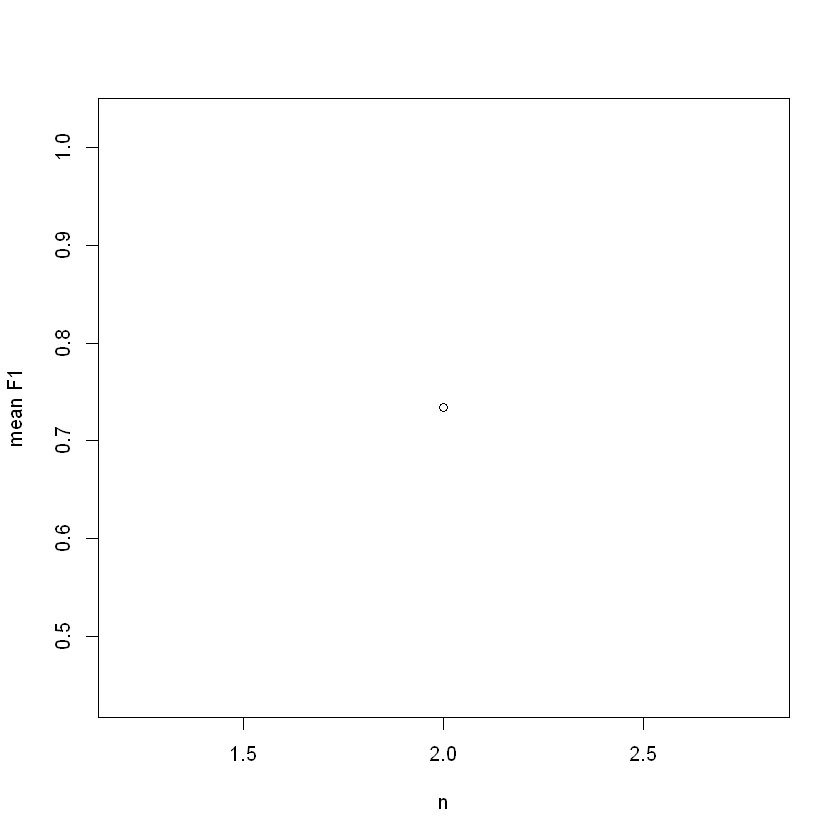

[1] "F1-Score Micro - 1 fold - 12 features: 0.744820801666602"
[1] "F1-Score Micro - 2 fold - 12 features: 0.744415724701979"
[1] "F1-Score Micro - 3 fold - 12 features: 0.742390339878863"
[1] "F1-Score Micro - 4 fold - 12 features: 0.741464449674009"
[1] "F1-Score Micro - 5 fold - 12 features: 0.744897959183674"


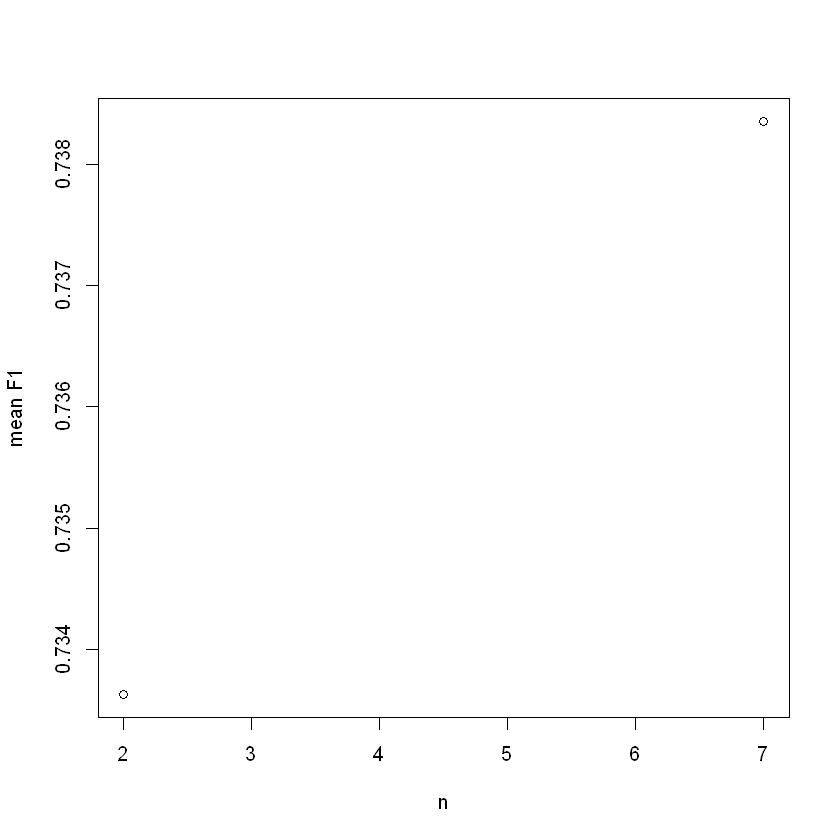

[1] "F1-Score Micro - 1 fold - 17 features: 0.755815747849234"
[1] "F1-Score Micro - 2 fold - 17 features: 0.754677674472436"
[1] "F1-Score Micro - 3 fold - 17 features: 0.753192392268817"
[1] "F1-Score Micro - 4 fold - 17 features: 0.75238223833957"
[1] "F1-Score Micro - 5 fold - 17 features: 0.755429960263879"


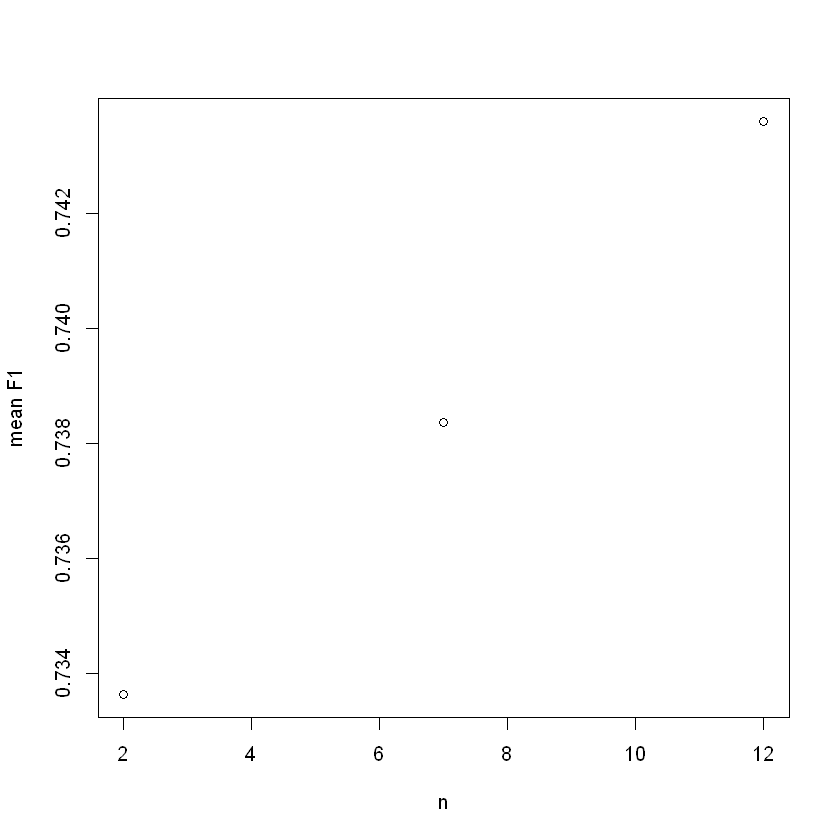

[1] "F1-Score Micro - 1 fold - 22 features: 0.756143667296786"
[1] "F1-Score Micro - 2 fold - 22 features: 0.75689595308823"
[1] "F1-Score Micro - 3 fold - 22 features: 0.752266502063964"
[1] "F1-Score Micro - 4 fold - 22 features: 0.752227923305428"
[1] "F1-Score Micro - 5 fold - 22 features: 0.755622854056556"


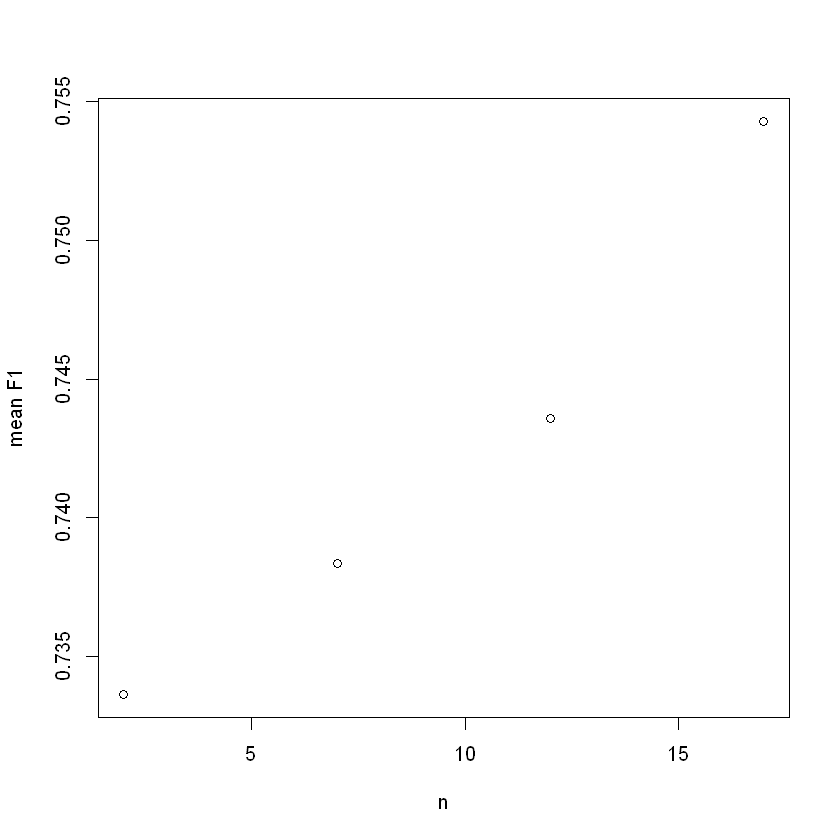

[1] "F1-Score Micro - 1 fold - 27 features: 0.757088846880907"
[1] "F1-Score Micro - 2 fold - 27 features: 0.756066509779715"
[1] "F1-Score Micro - 3 fold - 27 features: 0.752768025924926"
[1] "F1-Score Micro - 4 fold - 27 features: 0.752671579028587"
[1] "F1-Score Micro - 5 fold - 27 features: 0.755970062883376"


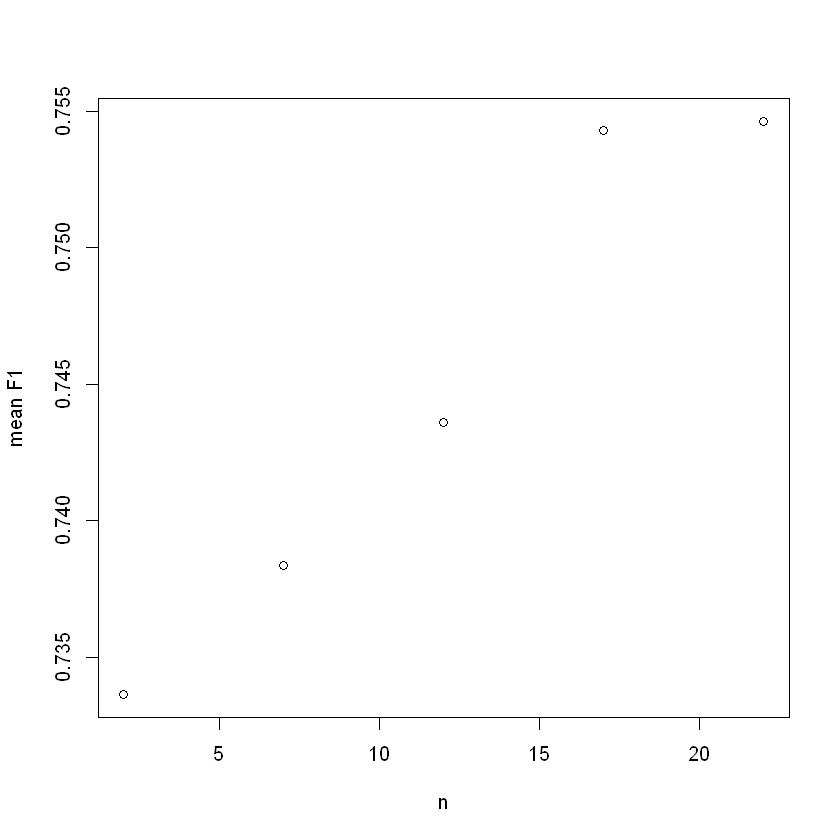

[1] "F1-Score Micro - 1 fold - 32 features: 0.755237066471201"
[1] "F1-Score Micro - 2 fold - 32 features: 0.755835037228502"
[1] "F1-Score Micro - 3 fold - 32 features: 0.754002546198064"
[1] "F1-Score Micro - 4 fold - 32 features: 0.753848231163921"
[1] "F1-Score Micro - 5 fold - 32 features: 0.756703059295552"


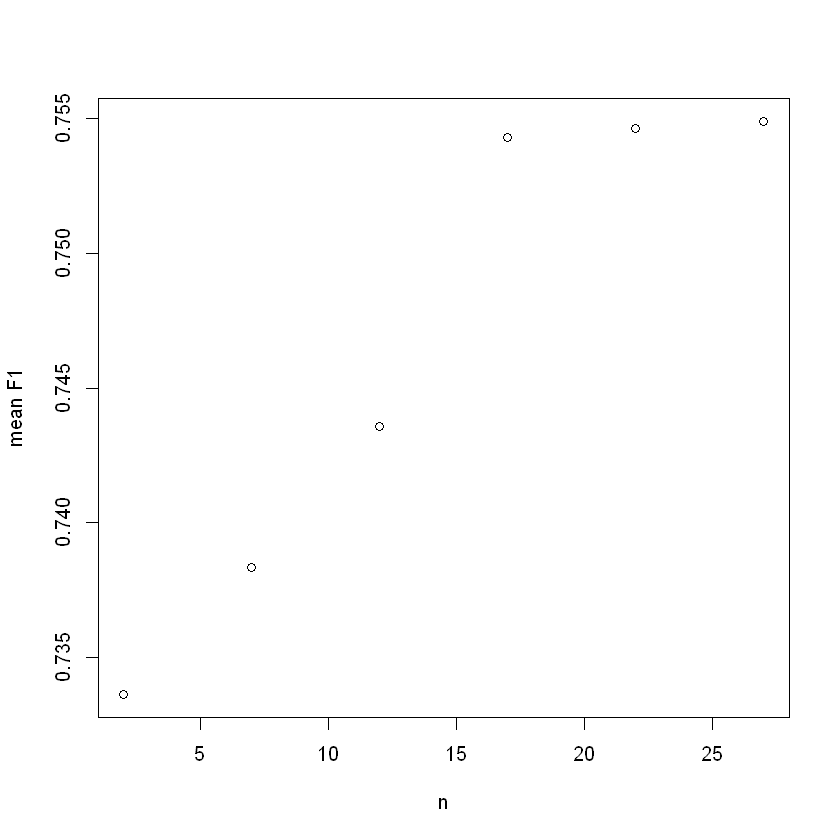

[1] "F1-Score Micro - 1 fold - 37 features: 0.754754831989507"
[1] "F1-Score Micro - 2 fold - 37 features: 0.756510165502874"
[1] "F1-Score Micro - 3 fold - 37 features: 0.754311176266348"
[1] "F1-Score Micro - 4 fold - 37 features: 0.753925388680992"
[1] "F1-Score Micro - 5 fold - 37 features: 0.75585432660777"


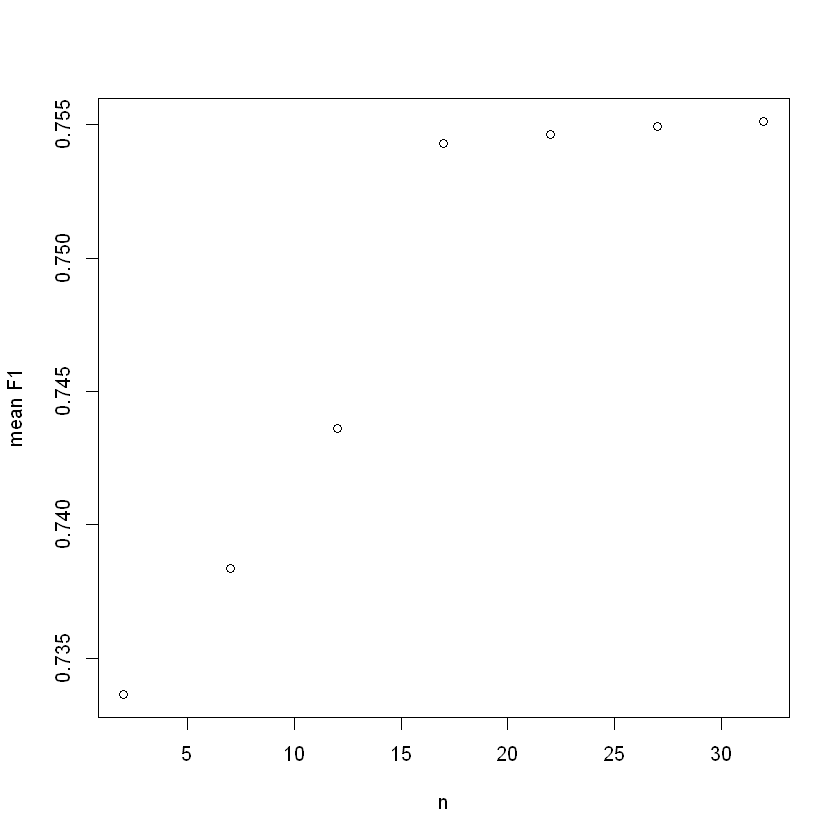

[1] "F1-Score Micro - 1 fold - 42 features: 0.754234018749277"
[1] "F1-Score Micro - 2 fold - 42 features: 0.756452297365071"
[1] "F1-Score Micro - 3 fold - 42 features: 0.753693916129779"
[1] "F1-Score Micro - 4 fold - 42 features: 0.755217777091933"
[1] "F1-Score Micro - 5 fold - 42 features: 0.756433007985803"


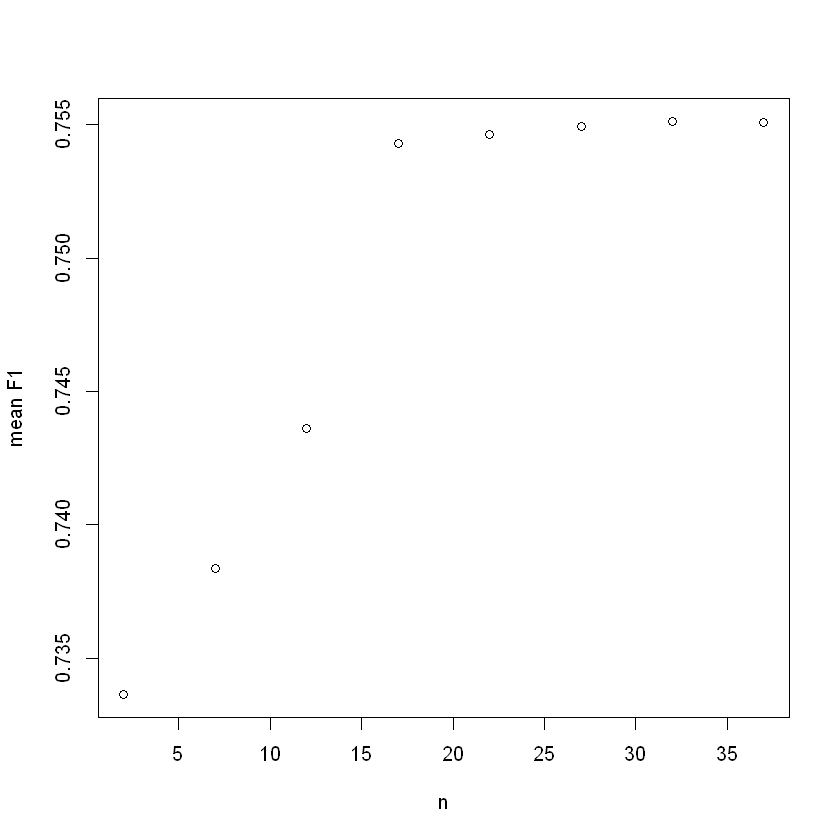

[1] "F1-Score Micro - 1 fold - 47 features: 0.756220824813857"
[1] "F1-Score Micro - 2 fold - 47 features: 0.758728444118668"
[1] "F1-Score Micro - 3 fold - 47 features: 0.753906099301724"
[1] "F1-Score Micro - 4 fold - 47 features: 0.752845183441997"
[1] "F1-Score Micro - 5 fold - 47 features: 0.757860422051618"


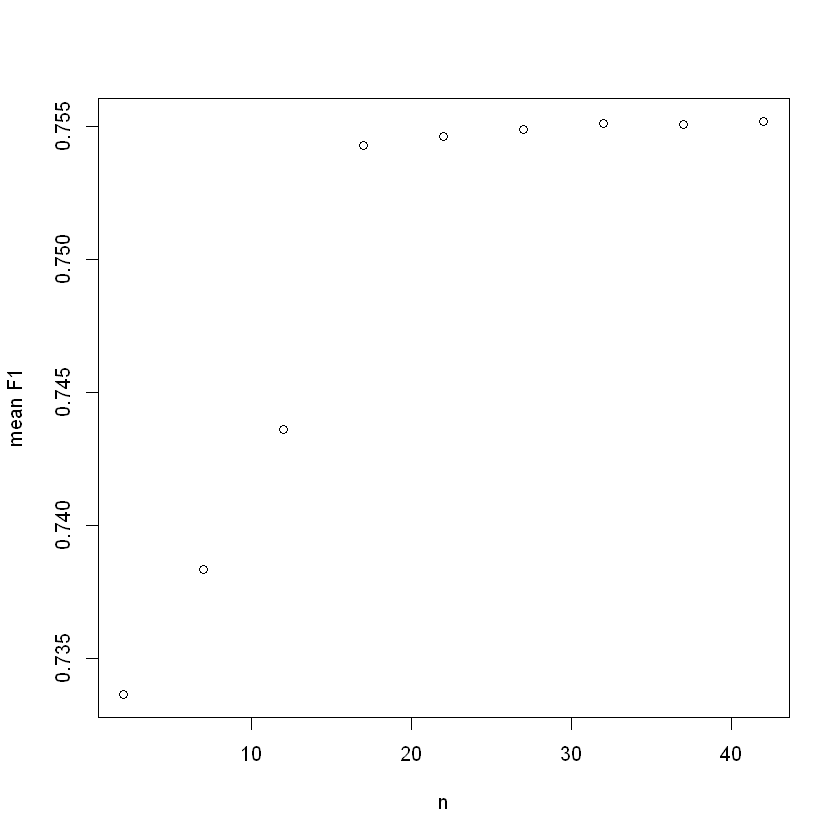

[1] "F1-Score Micro - 1 fold - 52 features: 0.755622854056556"
[1] "F1-Score Micro - 2 fold - 52 features: 0.757976158327225"
[1] "F1-Score Micro - 3 fold - 52 features: 0.751938582616411"
[1] "F1-Score Micro - 4 fold - 52 features: 0.755314223988272"
[1] "F1-Score Micro - 5 fold - 52 features: 0.757686817638208"


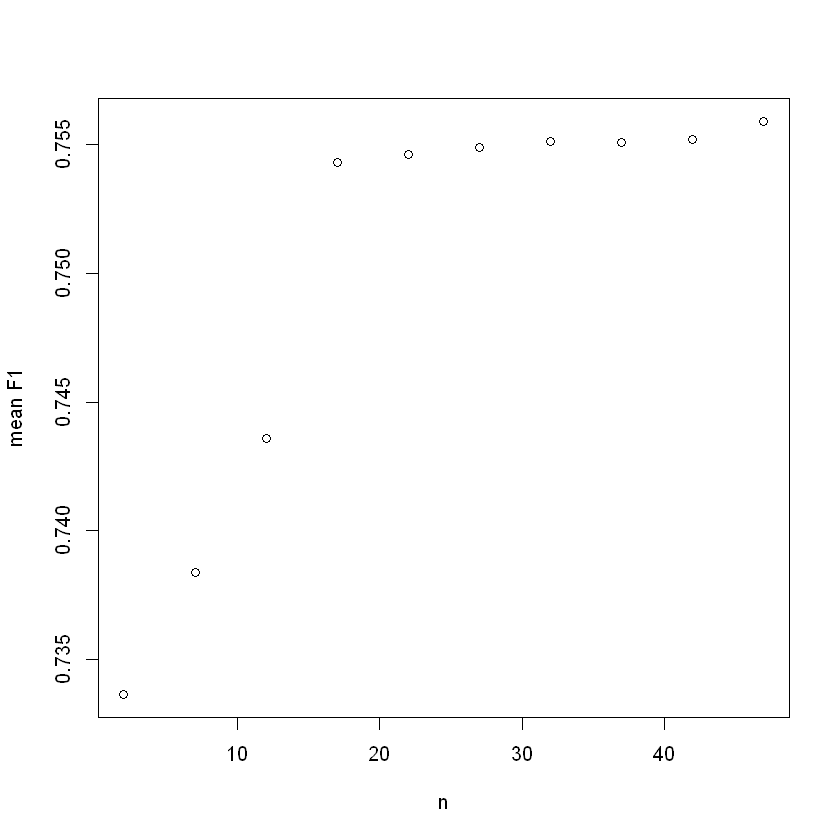

[1] "F1-Score Micro - 1 fold - 57 features: 0.755545696539485"
[1] "F1-Score Micro - 2 fold - 57 features: 0.758439103429652"
[1] "F1-Score Micro - 3 fold - 57 features: 0.753655337371243"
[1] "F1-Score Micro - 4 fold - 57 features: 0.754330465645615"
[1] "F1-Score Micro - 5 fold - 57 features: 0.757628949500405"


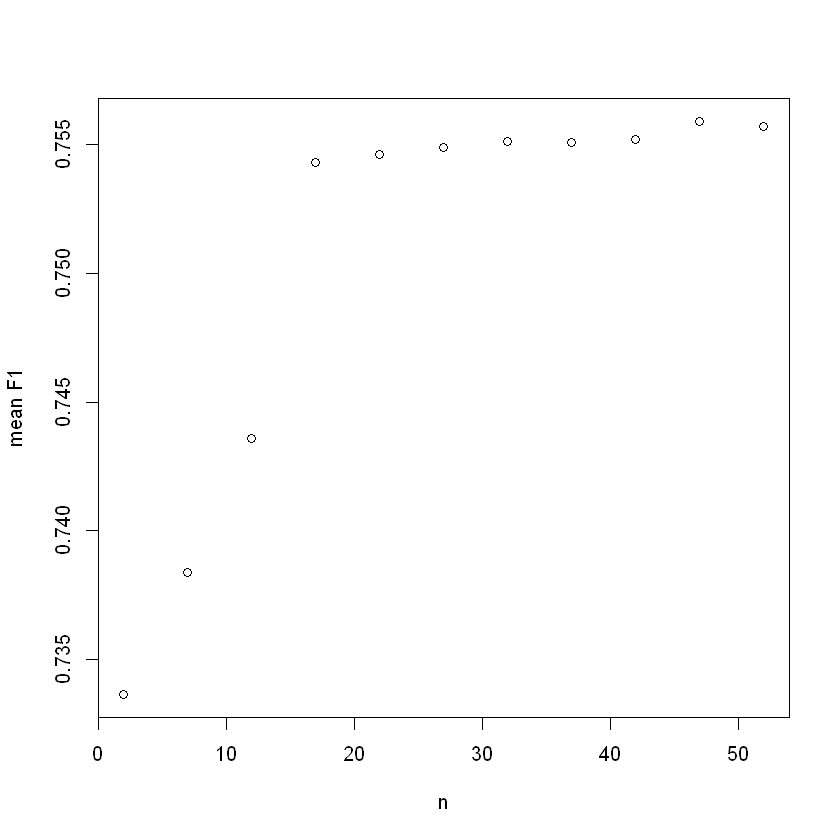

[1] "F1-Score Micro - 1 fold - 62 features: 0.754426912541954"
[1] "F1-Score Micro - 2 fold - 62 features: 0.757108136260175"
[1] "F1-Score Micro - 3 fold - 62 features: 0.753095945372478"
[1] "F1-Score Micro - 4 fold - 62 features: 0.754967015161452"
[1] "F1-Score Micro - 5 fold - 62 features: 0.75776397515528"


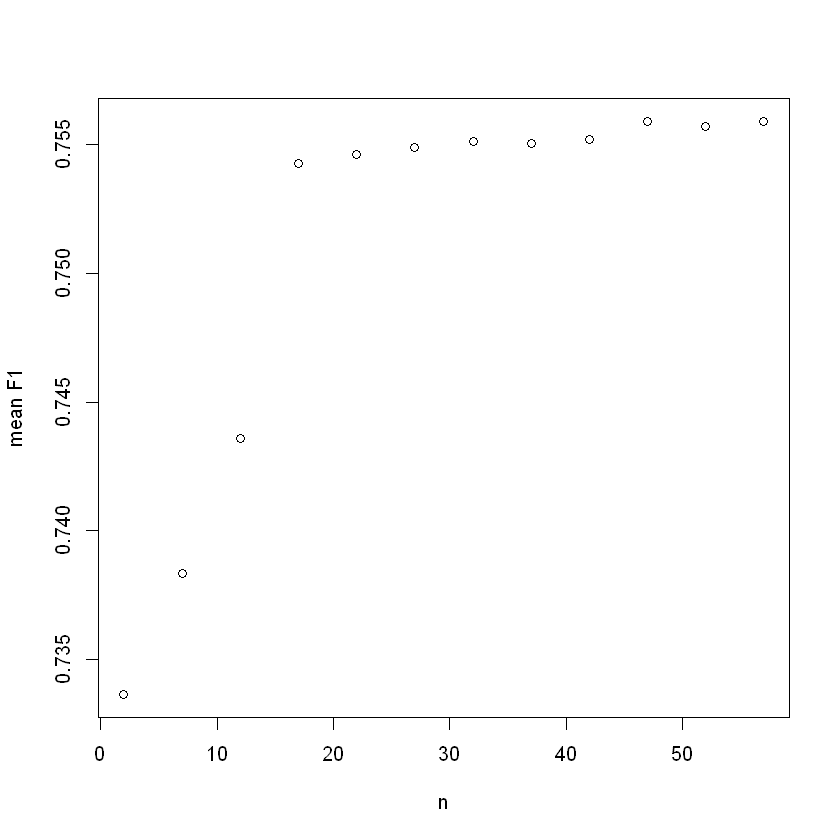

[1] "F1-Score Micro - 1 fold - 67 features: 0.754658385093168"
[1] "F1-Score Micro - 2 fold - 67 features: 0.757648238879673"
[1] "F1-Score Micro - 3 fold - 67 features: 0.753308128544423"
[1] "F1-Score Micro - 4 fold - 67 features: 0.753616758612708"
[1] "F1-Score Micro - 5 fold - 67 features: 0.757127425639443"


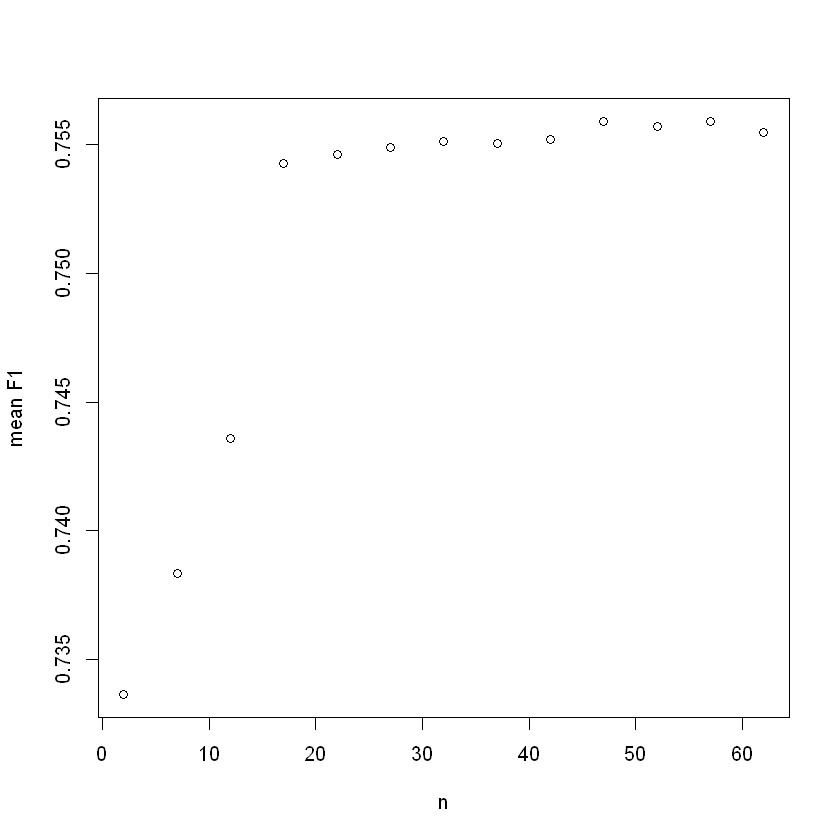

,n,fold,F1
,<dbl>,<dbl>,<dbl>
1,2,1,0.7347710
2,2,2,0.7347517
3,2,3,0.7333822
4,2,4,0.7310096
5,2,5,0.7342116
6,7,1,0.7392655
7,7,2,0.7392462
8,7,3,0.7381467
9,7,4,0.7367578


,n,mean F1
,<dbl>,<dbl>
1,2,0.7336252
2,2,0.7336252
3,7,0.7383550
4,2,0.7336252
5,7,0.7383550
6,12,0.7435979
7,2,0.7336252
8,7,0.7383550
9,12,0.7435979


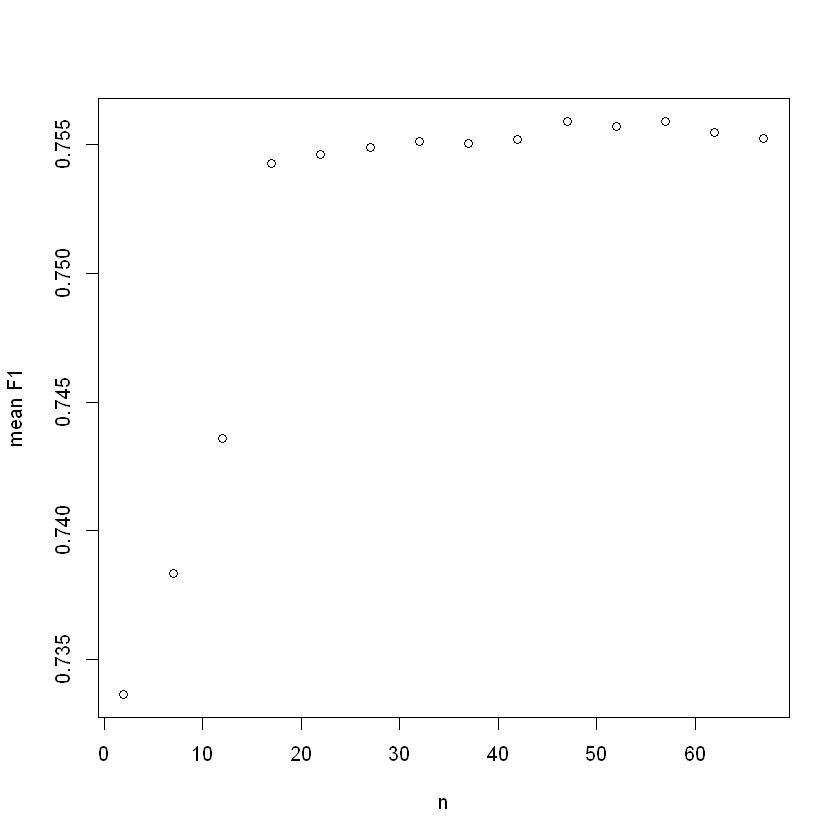

In [7]:
# drop = F is used to preserve the structure of the data as data.frame (see https://www.r-bloggers.com/2018/02/r-tip-use-drop-false-with-data-frames/)
set.seed(2) 
CV_folds <- 5
targets<-which(grepl('damage_grade',colnames(dataNN)))
n<-ncol(dataNN[,-targets])
N<-nrow(dataNN[,-targets])
size_CV <-floor(N/CV_folds)

accuracy_vec <- data.frame(matrix(ncol = 3, nrow = 0))
colnames(accuracy_vec)<-c('n','fold','F1')


for (nb_features in seq(2,n,5)) {
    for (i in 1:CV_folds) {
    
        targets<-which(grepl('damage_grade',colnames(dataNN)))
        idx_ts<-(((i-1)*size_CV+1):(i*size_CV))  ### idx_ts represents the indices of the test set the i-th fold
        X_ts<-dataNN[idx_ts,-targets]  
        Y_ts<-dataNN[idx_ts,targets]      
        
        idx_tr<-setdiff(1:N,idx_ts) ### idx_tr represents  indices of the training sefor the i-th fold
        X_tr<-dataNN[idx_tr,-targets]
        Y_tr<-dataNN[idx_tr,targets]                          

        # Create a dataset including only the first nb_features selected variables
        DS<-cbind(X_tr[,rankingNN[1:nb_features],drop=F],Y_tr)
        
        # Model fit (using lm function)
        targets<-which(grepl('damage_grade',colnames(DS)))
        normalizer<-layer_normalization(axis = -1L)  %>%  
        adapt(as.matrix(DS[,-targets]))

        neuralmodel <- keras_model_sequential() %>% 
        normalizer  %>% 
        layer_dense(37, activation = 'relu') %>%
        layer_dense(3,activation='softmax')

        neuralmodel %>% compile(
            loss = 'categorical_crossentropy',
            optimizer = optimizer_adam(0.001),
            metrics=c('AUC')
        )
        
        model_history <- neuralmodel %>% fit(
        as.matrix(DS[,-targets]),
        as.matrix(DS[,targets]),
        validation_split = 0.2,
        verbose = 0,
        epochs = 30
        )

        # Model prediction
        yhat <- predict(neuralmodel, as.matrix(X_ts[,ranking[1:nb_features]]))

        yhaty <- classConverter(yhat,Y_ts)

        accuracy<-F1_Score_micro(yhaty[[2]][,],yhaty[[1]][,])
        
        # Cross-validation error = F1
        accuracy_vec[nrow(accuracy_vec)+1,]<-c(nb_features,i,accuracy)
        print(paste("F1-Score Micro -",i,"fold -", nb_features,'features:',accuracy))
        rm('neuralmodel','model_history')
    }
}

accuracy_vec

,n,mean F1
,<dbl>,<dbl>
1,2,0.7336252
2,7,0.7383550
3,12,0.7435979
4,17,0.7542996
5,22,0.7546314
6,27,0.7549130
7,32,0.7551252
8,37,0.7550712
9,42,0.7552062


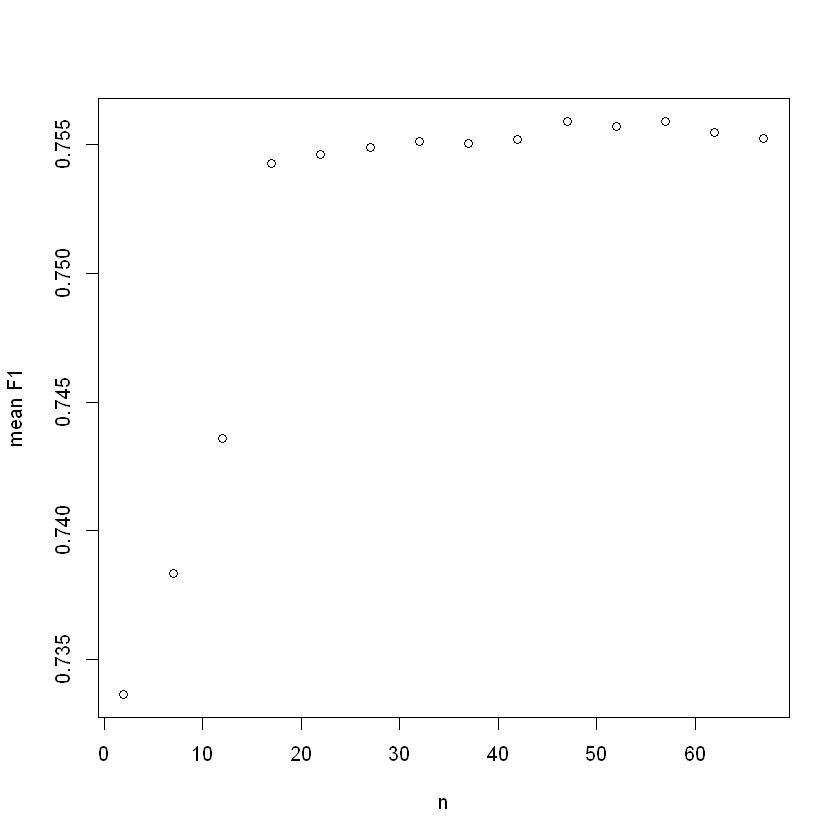

In [9]:
meanF1 <- data.frame(matrix(ncol = 2, nrow = 0))

colnames(meanF1)<-c('n','mean F1')
    for (l in seq(2,nb_features,5)){
            meanF1[nrow(meanF1)+1,]<-c(l,mean(filter(accuracy_vec,(n==l))$F1))
    }
    plot(meanF1)
meanF1